## 6. Derivative of Gaussian:


(a) Answers for part (a) is included in the report.

(b) Using NumPy, compute normalized 5×5 kernels corresponding to the derivatives of a Gaussian for σ = 2 in the x- and y-directions.


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sigma = 2
h_size = 2   

x = np.arange(-h_size, h_size+1, 1)
y = np.arange(-h_size, h_size+1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))

gx = -(X/(sigma**2)) * g
gy = -(Y/(sigma**2)) * g

print(gx)
print(gy)

[[ 0.00731873  0.01064869  0.01206654  0.01064869  0.00731873]
 [ 0.00532434  0.00774687  0.00877836  0.00774687  0.00532434]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.00532434 -0.00774687 -0.00877836 -0.00774687 -0.00532434]
 [-0.00731873 -0.01064869 -0.01206654 -0.01064869 -0.00731873]]
[[ 0.00731873  0.00532434 -0.         -0.00532434 -0.00731873]
 [ 0.01064869  0.00774687 -0.         -0.00774687 -0.01064869]
 [ 0.01206654  0.00877836 -0.         -0.00877836 -0.01206654]
 [ 0.01064869  0.00774687 -0.         -0.00774687 -0.01064869]
 [ 0.00731873  0.00532434 -0.         -0.00532434 -0.00731873]]


(c) Visualize a 51×51 derivative-of-Gaussian kernel (for either the x or y direction) as a 3D surface plot, where the kernel coefficients represent the height.

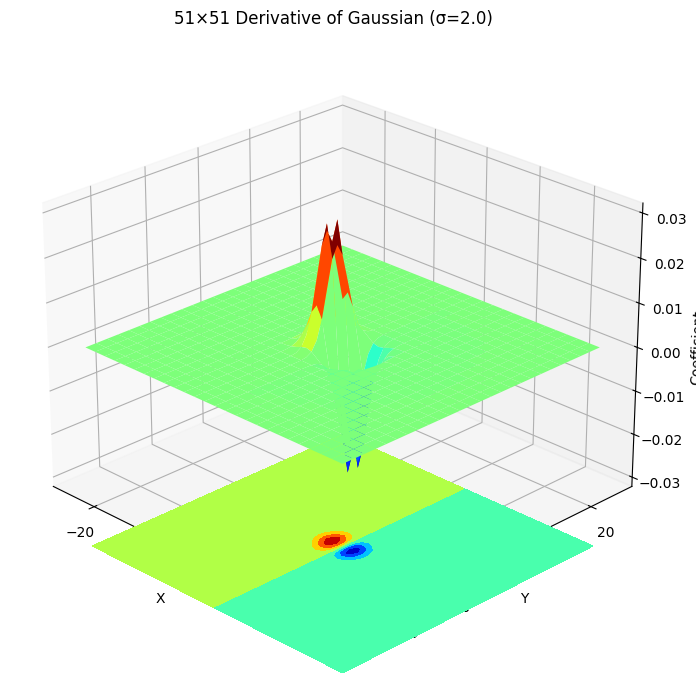

In [5]:
h_size_big = 25     
sigma_big  = 2.0

x_big = np.arange(-h_size_big, h_size_big + 1, 1)
y_big = np.arange(-h_size_big, h_size_big + 1, 1)
Y_big, X_big = np.meshgrid(x_big, y_big)

g_51x51 = 1 / (2 * np.pi * sigma_big**2) * np.exp(-(X_big**2 + Y_big**2) / (2 * sigma_big**2))
gx_51x51 = -(X_big / (sigma_big**2)) * g_51x51
gx_51x51 = gx_51x51 / np.sum(np.abs(gx_51x51))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_big, Y_big, gx_51x51, cmap='jet',
                rstride=2, cstride=2, linewidth=0.1, antialiased=True)

ax.contourf(X_big, Y_big, gx_51x51, zdir='z',
            offset=gx_51x51.min() * 1.5, cmap='jet')

ax.set_title(f'51×51 Derivative of Gaussian (σ={sigma_big})', fontsize=12)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Coefficient')

ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

(d) Apply the computed derivative-of-Gaussian kernels to a given grayscale image to obtain the image gradients in the horizontal and vertical directions.

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [7]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

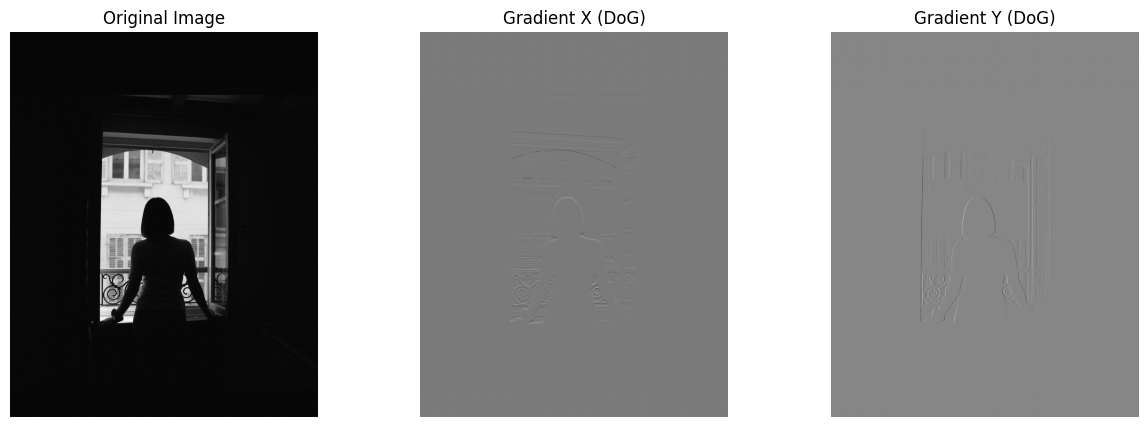

In [8]:
sigma = 2
h_size = 2   
x = np.arange(-h_size, h_size+1, 1)
y = np.arange(-h_size, h_size+1, 1)
Y, X = np.meshgrid(x, y)

g = 1/(2*np.pi*sigma**2)*np.exp(-(X**2 + Y**2)/(2*sigma**2))

gx = -(X/(sigma**2)) * g
gy = -(Y/(sigma**2)) * g

fx = cv.filter2D(f, cv.CV_32F, gx)
fy = cv.filter2D(f, cv.CV_32F, gy)

fx = cv.normalize(fx, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
fy = cv.normalize(fy, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(fx, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gradient X (DoG)')
ax[1].axis('off')
ax[2].imshow(fy, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gradient Y (DoG)')
ax[2].axis('off')
plt.show()


(e) Using OpenCV, compute the image gradients by applying cv.Sobel().  Compare the results with those obtained above and comment on any observed differences.

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [10]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\woman_standing.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

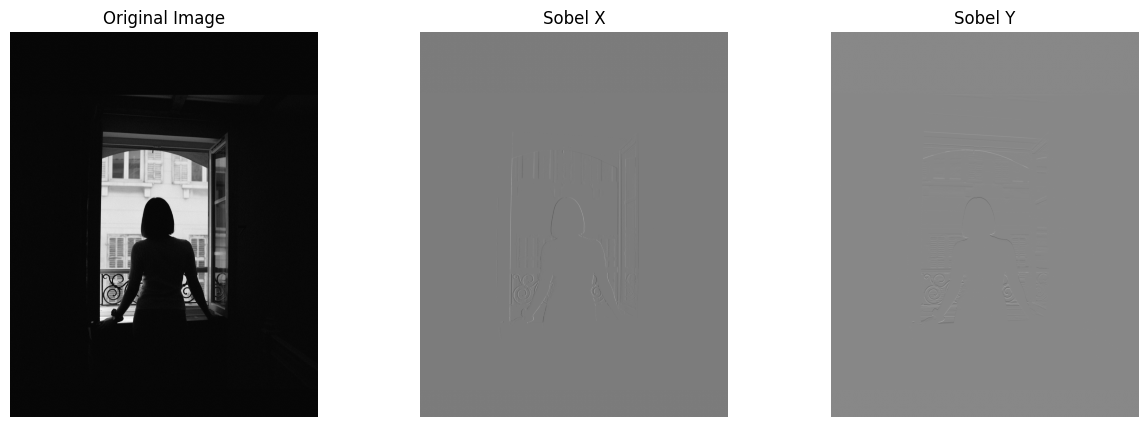

In [11]:
fx = cv.Sobel(f, cv.CV_32F, 1, 0, ksize=3)
fy = cv.Sobel(f, cv.CV_32F, 0, 1, ksize=3)

fx = cv.normalize(fx, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
fy = cv.normalize(fy, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(fx, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Sobel X')
ax[1].axis('off')

ax[2].imshow(fy, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Sobel Y')
ax[2].axis('off')

plt.show()